In [1]:
import pandas as pd
import numpy as np
import pingouin as pg
import plotly.express as px
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv("data/blinded_data.csv")
df

,Effectors,Tars_per_well,E:T,Mean Result,SD,CV%,SE
0,CAR,5000,20.000,73.676904,1.279857,1.737121,0.904995
1,CAR,5000,10.000,68.987573,3.462388,5.018857,2.448278
2,CAR,5000,5.000,63.998539,4.818831,7.529595,3.407428
3,CAR,5000,2.500,55.051170,2.202944,4.001629,1.557716
4,CAR,5000,1.250,37.858191,2.885549,7.621994,2.040391
5,CAR,5000,0.625,21.991957,3.677260,16.720931,2.600215
6,CAR,10000,20.000,78.715553,1.742235,2.213330,1.231946
7,CAR,10000,10.000,77.947703,2.025196,2.598147,1.432030
8,CAR,10000,5.000,73.910073,7.885710,10.669331,5.576039
9,CAR,10000,2.500,76.979353,1.810105,2.351416,1.279937


# What does each column mean?

- Effectors: Type of the treatment cells,
- Tars_per_well: Initial number of target cells in a well,
- E:T: initial E to T ratio,
- Mean Result (Guess): Average percentage kill of the target cells at the end, compare to intial value (e.g. 73 means 73% of initial planted T cells are eliminated) (remark: there is a negative value, meaning that in that scenario, T cells grew a bit),
- SD (Guess): Standard deviation of the percentage kill,
- CV%: calculated as SD/Mean Result,
- SE: calculated as SD/sqrt(number of trials), from there we can infer number of trials is all 2 for different combinations of effectos and TPW.

In [3]:
df["log E:T"] = np.log(df["E:T"])
df["log Tars_per_well"] = np.log(df["Tars_per_well"])
df["interaction"] = df["E:T"] * df["Tars_per_well"]
df["log interaction"] = df["log E:T"] * df["log Tars_per_well"]
df["Group"] = df["Effectors"] + " - " + df["Tars_per_well"].astype(str)

In [4]:
vars_to_plot = ["E:T", "log E:T", "Mean Result", "SD", "CV%", "SE"]

for (eff, tpw), group in df.groupby(["Effectors", "Tars_per_well"]):
    fig = px.scatter_matrix(group, dimensions=vars_to_plot, title=f"Scatter Matrix for {eff}, Tars={tpw}", labels={col: col for col in vars_to_plot})
    fig.update_traces(diagonal_visible=False, marker=dict(size=8))
    fig.update_layout(height=700)
    fig.show()

Mean result and E:T or log E:T seem to have some nice and strong relation, let's explore that.

In [5]:
fig = px.line(
    df.sort_values(by=["Effectors", "Tars_per_well", "E:T"]),
    x="E:T",
    y="Mean Result",
    color="Group",
    markers=True,
    title="E:T vs Mean Result by Effector and Target Count",
    labels={"E:T": "Effector:Target Ratio", "Mean Result": "Mean % Killing"},
    height=600,
)
fig.update_traces(mode="lines+markers", marker=dict(size=10))
fig.update_traces(mode="lines+markers")
fig.update_layout(template="simple_white")
fig

They look 'log like', so it's probably a good idea to log scale x axis.

In [6]:
fig = px.line(
    df.sort_values(by=["Effectors", "Tars_per_well", "E:T"]),
    x="log E:T",
    y="Mean Result",
    color="Group",
    markers=True,
    title="E:T vs Mean Result by Effector and Target Count",
    labels={"E:T": "Effector:Target Ratio", "Mean Result": "Mean % Killing"},
    height=600,
)

fig.update_traces(mode="lines+markers", marker=dict(size=10))
fig.update_traces(mode="lines+markers")
fig.update_layout(template="simple_white")
fig

They does look some how linear. Let's try a regression.

In [7]:
results = []
for (eff, tpw), group in df.groupby(["Effectors", "Tars_per_well"]):
    x = group["log E:T"]
    y = group["Mean Result"]
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    results.append(
        {
            "Effectors": eff,
            "Tars_per_well": tpw,
            "slope": slope,
            "intercept": intercept,
            "r_value": r_value,
            "r_squared": r_value**2,  # pyright: ignore[reportOperatorIssue]
            "p_value": p_value,
            "std_err": std_err,
        }
    )

regression_df = pd.DataFrame(results)
regression_df

,Effectors,Tars_per_well,slope,intercept,r_value,r_squared,p_value,std_err
0,CAR,5000,14.870486,34.814649,0.964904,0.931040,0.001826,2.023532
1,CAR,10000,9.661839,56.191677,0.842574,0.709930,0.035224,3.087970
2,CAR,20000,3.658566,47.125526,0.783988,0.614636,0.064952,1.448462
3,UTD,10000,3.110480,-0.850660,0.934823,0.873894,0.006234,0.590793


This tells us a few things.

1. E:T does matter: for each Effectors / TPW combination, the **slope** of linear regression fitting x = log E:T, y = mean killing percentage is always **positive**, meaning higher (log) E:T ratio implies higher killing percentage
2. BUT: as TPW increase, the linear regression has weaker explanation power - R^2 is lower, and p-value is higher. This in particular means that E:T ratio is NOT explaining everything.

So let's try to put TPW as a feature, not just a label, it's now a bit harder to visualize so let's skip that part. Let's also focus on CAR from this point.

In [8]:
sub_df = df[df["Effectors"] == "CAR"].copy()
results = pg.linear_regression(sub_df[["E:T", "Tars_per_well", "interaction"]], sub_df["Mean Result"], add_intercept=True)
results

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,45.970994,9.462244,4.858361,0.000253,0.396917,0.267684,25.676499,66.265488
1,E:T,2.429988,1.003745,2.420922,0.029655,0.396917,0.267684,0.277169,4.582807
2,Tars_per_well,0.000320,0.000715,0.446750,0.661889,0.396917,0.267684,-0.001215,0.001854
3,interaction,-0.000101,0.000076,-1.331468,0.204310,0.396917,0.267684,-0.000264,0.000062


In [9]:
results = pg.linear_regression(sub_df[["log E:T", "log Tars_per_well", "log interaction"]], sub_df["Mean Result"], add_intercept=True)
results

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,-35.747748,58.528782,-0.610772,0.551138,0.64555,0.569596,-161.279501,89.784005
1,log E:T,83.887349,33.813326,2.480896,0.026423,0.64555,0.569596,11.364979,156.409719
2,log Tars_per_well,8.880421,6.342719,1.400097,0.183254,0.64555,0.569596,-4.723358,22.484199
3,log interaction,-8.087691,3.664324,-2.207144,0.044500,0.64555,0.569596,-15.946884,-0.228498


So the log E:T and log TPW (Tars_per_well) do have some explanation power, but overall I'm not satisfied (high p-value and rather low R^2). Probably we should try some other things.

Let's introduce the so-called hill equation:

$$f(x) = A \cdot \frac{x^n}{K^n + x^n}$$

Where $f(x)$ is the mean percentage killing. x is the E:T ratio, A is the maximum possible killing, K is the E:T ratio at A/2, and n is a steepness coefficient. We are fitting our data to the best parameters A, K and n.

TPW = 5000
	A = 74.336, K = 1.198, n = 1.326
	R^2 = 0.9979
	Residual Sum of Squares (RSS): 4.122
TPW = 10000
	A = 78.047, K = 0.603, n = 2.008
	R^2 = 0.9803
	Residual Sum of Squares (RSS): 21.810
TPW = 20000
	A = 54.900, K = 0.412, n = 2.434
	R^2 = 0.9120
	Residual Sum of Squares (RSS): 16.116


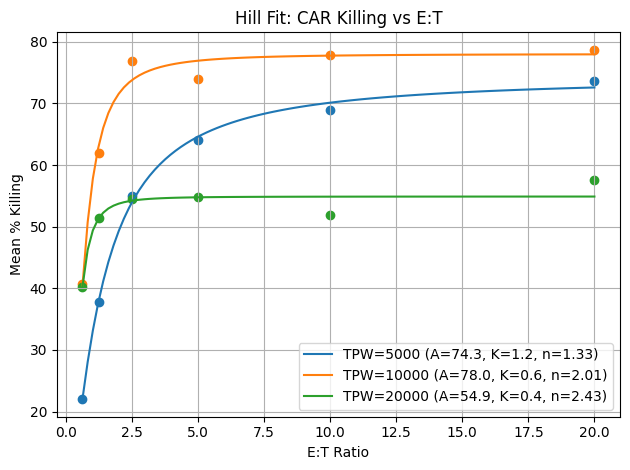

In [10]:
def hill(x, A, K, n):
    return A * (x**n) / (K**n + x**n)


for tpw in sub_df["Tars_per_well"].unique():
    subset = sub_df[sub_df["Tars_per_well"] == tpw]
    x = subset["E:T"].to_numpy()
    y = subset["Mean Result"].to_numpy()
    try:
        popt, _ = curve_fit(hill, x, y, bounds=([0, 0, 0], [100, 100, 5]))
        A, K, n = popt
        xfit = np.linspace(x.min(), x.max(), 100)
        yfit = hill(xfit, *popt)
        plt.plot(xfit, yfit, label=f"TPW={tpw} (A={A:.1f}, K={K:.1f}, n={n:.2f})")
        plt.scatter(x, y)
        y_pred = hill(x, *popt)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        print(f"TPW = {tpw}")
        print(f"\tA = {A:.3f}, K = {K:.3f}, n = {n:.3f}")
        print(f"\tR^2 = {r_squared:.4f}")
        print(f"\tResidual Sum of Squares (RSS): {ss_res:.3f}")
    except RuntimeError:
        print(f"Fit failed for TPW={tpw}")
plt.xlabel("E:T Ratio")
plt.ylabel("Mean % Killing")
plt.title("Hill Fit: CAR Killing vs E:T")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Looks way better. What can we get from the result:

0. R^2 is strong for each case - Hill equation model looks good
1. Max killing percentage (A) decreases with TPW  
   Possible explanation: Not really changing from TPW = 5000 to 10000, but at very high tumor load, CAR T cells become overwhelmed or exhausted before achieving full clearance.
2. K decreases with TPW  
   Possible explanation: K is like an inflection point. Tells us how many E (per T) to get half of max killing, so small K means the system responds earlier. The behavior we see here means that as E is outnumbered, the system is more sensitive to E:T.
3. n increases with TPW  
   Possible explanation: n is like a threshold. With higher TPW, killing goes from little to most over a narrower E:T window.

OK, what about variation?

Let's see summaries of SD, CV%, and SE when grouping data by TPW or E:T ratio.

In [11]:
tpw_groups = sorted(sub_df["Tars_per_well"].unique())
summary_tpw = []
for tpw in tpw_groups:
    subset = sub_df[sub_df["Tars_per_well"] == tpw]
    mean_sd = subset["SD"].mean()
    mean_cv = subset["CV%"].mean()
    mean_se = subset["SE"].mean()
    max_cv = subset["CV%"].max()
    min_cv = subset["CV%"].min()
    corr = subset[["E:T", "CV%"]].corr().iloc[0, 1]
    corr_log = subset[["log E:T", "CV%"]].corr().iloc[0, 1]
    summary_tpw.append(
        {
            "TPW": tpw,
            "Mean SD": mean_sd,
            "Mean CV%": mean_cv,
            "Mean SE": mean_se,
            "Max CV%": max_cv,
            "Min CV%": min_cv,
            "Corr(E:T, CV%)": corr,
            "Corr(log E:T, CV%)": corr_log,
        }
    )
summary_tpw_df = pd.DataFrame(summary_tpw)
summary_tpw_df

,TPW,Mean SD,Mean CV%,Mean SE,Max CV%,Min CV%,"Corr(E:T, CV%)","Corr(log E:T, CV%)"
0,5000,3.054471,7.105021,2.159837,16.720931,1.737121,-0.658665,-0.812591
1,10000,2.728971,3.795944,1.929674,10.669331,0.734920,-0.108633,0.164067
2,20000,1.657284,3.355574,1.171877,6.345475,0.488663,-0.286395,-0.580607


In [12]:
et_groups = sorted(sub_df["E:T"].unique())
summary_et = []
for et in et_groups:
    subset = sub_df[sub_df["E:T"] == et]
    mean_sd = subset["SD"].mean()
    mean_cv = subset["CV%"].mean()
    mean_se = subset["SE"].mean()
    max_cv = subset["CV%"].max()
    min_cv = subset["CV%"].min()
    corr = subset[["Tars_per_well", "CV%"]].corr().iloc[0, 1]
    corr_log = subset[["log Tars_per_well", "CV%"]].corr().iloc[0, 1]
    summary_et.append(
        {
            "E:T": et,
            "Mean SD": mean_sd,
            "Mean CV%": mean_cv,
            "Mean SE": mean_se,
            "Max CV%": max_cv,
            "Min CV%": min_cv,
            "Corr(TPW, CV%)": corr,
            "Corr(log TPW, CV%)": corr_log,
        }
    )
summary_et_df = pd.DataFrame(summary_et)
summary_et_df

,E:T,Mean SD,Mean CV%,Mean SE,Max CV%,Min CV%,"Corr(TPW, CV%)","Corr(log TPW, CV%)"
0,0.625,2.177229,7.933775,1.539533,16.720931,0.734920,-0.482838,-0.639631
1,1.250,2.499250,5.240796,1.767237,7.621994,3.891872,-0.803825,-0.901759
2,2.500,1.864020,3.084716,1.318061,4.001629,2.351416,-0.500225,-0.654850
3,5.000,4.324101,6.229196,3.057601,10.669331,0.488663,-0.802489,-0.675270
4,10.000,2.464278,3.761679,1.742508,5.018857,2.598147,-0.389766,-0.556779
5,20.000,1.552576,2.262917,1.097837,2.838299,1.737121,0.993702,0.996972


How to read the table:

| E:T | Mean SD | Mean CV% | Mean SE | Max CV% | Min CV% | Corr(TPW, CV%) | Corr(log TPW, CV%) |
| --- | ------- | -------- | ------- | ------- | ------- | -------------- | ------------------ |
| 0.625 | 2.177229 | 7.933775 | 1.539533 | 16.720931 | 0.734920 | -0.482838 | -0.639631 |

Means: If we look at the three lines in df that has Effector = CAR and E:T = 0.625, their SD has mean 2.177, CV% has mean 7.93, etc. and the correlation between TPW and CV% is -0.48, between log TPW and CV% is -0.63.

For the first table, it can be interpreted similarly but are group by TPW.

What do we get from these result?

First table (group by TPW):

1. At low TPW (5000), adding more effectors reliably reduces variability
2. At medium TPW (10000), variability is already low and doesn’t change much
3. At high TPW (20000), a moderate negative trend re-emerges, more effectors do help, but not as dramatically

Second table (group by E:T ratio):

1. In general, higher E:T implies lower variability. And within the same E:T ratio, higher TPW implies lower variability
2. At the highest E:T = 20, kill is high, consistent, as expected, but higher TPW implies higher variability.

# Hill Equation with Training and Testing

In [13]:
sub_df_test = sub_df.iloc[[2, 4, 7, 8, 14, 16]].copy()
sub_df_train = sub_df.iloc[[0, 1, 3, 5, 6, 9, 10, 11, 12, 13, 15, 17]].copy()

In [14]:
sub_df_test

,Effectors,Tars_per_well,E:T,Mean Result,SD,CV%,SE,log E:T,log Tars_per_well,interaction,log interaction,Group
2,CAR,5000,5.00,63.998539,4.818831,7.529595,3.407428,1.609438,8.517193,25000.0,13.707894,CAR - 5000
4,CAR,5000,1.25,37.858191,2.885549,7.621994,2.040391,0.223144,8.517193,6250.0,1.900557,CAR - 5000
7,CAR,10000,10.00,77.947703,2.025196,2.598147,1.432030,2.302585,9.210340,100000.0,21.207592,CAR - 10000
8,CAR,10000,5.00,73.910073,7.885710,10.669331,5.576039,1.609438,9.210340,50000.0,14.823471,CAR - 10000
14,CAR,20000,5.00,54.794813,0.267762,0.488663,0.189336,1.609438,9.903488,100000.0,15.939048,CAR - 20000
16,CAR,20000,1.25,51.420527,2.001221,3.891872,1.415077,0.223144,9.903488,25000.0,2.209899,CAR - 20000


In [15]:
sub_df_train

,Effectors,Tars_per_well,E:T,Mean Result,SD,CV%,SE,log E:T,log Tars_per_well,interaction,log interaction,Group
0,CAR,5000,20.000,73.676904,1.279857,1.737121,0.904995,2.995732,8.517193,100000.0,25.515231,CAR - 5000
1,CAR,5000,10.000,68.987573,3.462388,5.018857,2.448278,2.302585,8.517193,50000.0,19.611562,CAR - 5000
3,CAR,5000,2.500,55.051170,2.202944,4.001629,1.557716,0.916291,8.517193,12500.0,7.804225,CAR - 5000
5,CAR,5000,0.625,21.991957,3.677260,16.720931,2.600215,-0.470004,8.517193,3125.0,-4.003112,CAR - 5000
6,CAR,10000,20.000,78.715553,1.742235,2.213330,1.231946,2.995732,9.210340,200000.0,27.591714,CAR - 10000
9,CAR,10000,2.500,76.979353,1.810105,2.351416,1.279937,0.916291,9.210340,25000.0,8.439350,CAR - 10000
10,CAR,10000,1.250,62.040355,2.610981,4.208521,1.846243,0.223144,9.210340,12500.0,2.055228,CAR - 10000
11,CAR,10000,0.625,40.766573,0.299602,0.734920,0.211850,-0.470004,9.210340,6250.0,-4.328893,CAR - 10000
12,CAR,20000,20.000,57.627338,1.635636,2.838299,1.156569,2.995732,9.903488,400000.0,29.668197,CAR - 20000
13,CAR,20000,10.000,51.942026,1.905251,3.668034,1.347216,2.302585,9.903488,200000.0,22.803623,CAR - 20000


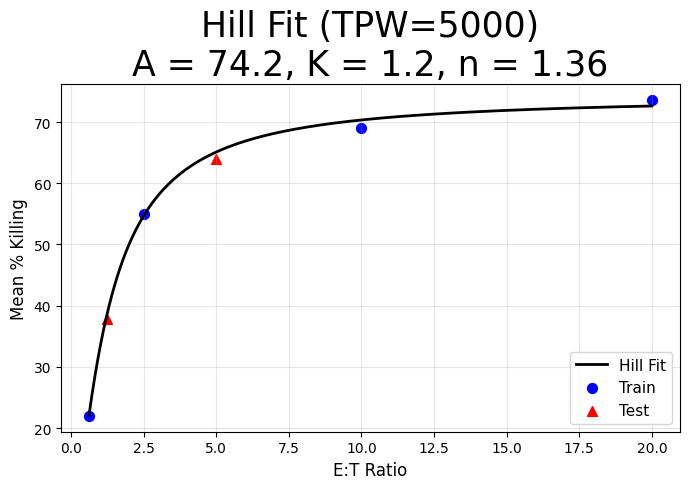

TPW = 5000
	A = 74.162, K = 1.171, n = 1.358
	Train RSS = 3.13
	Test  RSS = 1.93


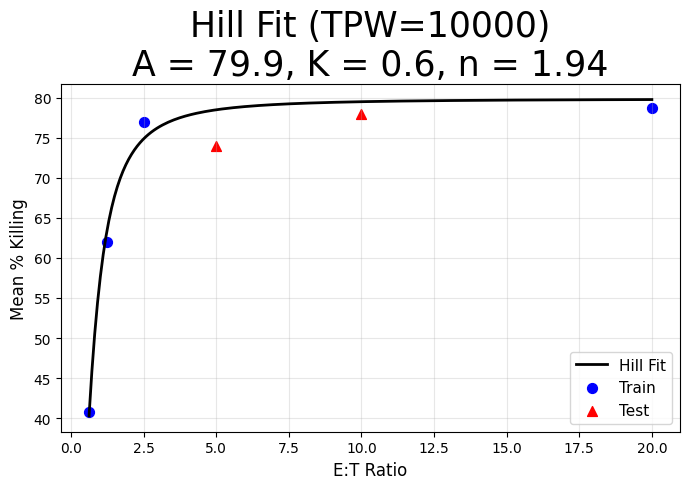

TPW = 10000
	A = 79.857, K = 0.619, n = 1.937
	Train RSS = 8.18
	Test  RSS = 23.31


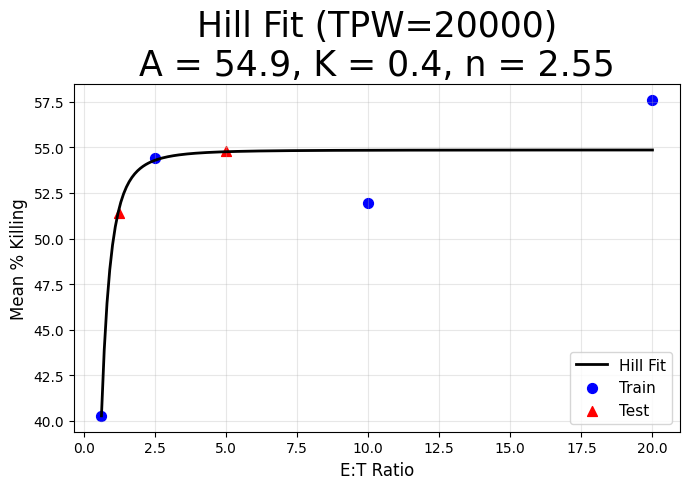

TPW = 20000
	A = 54.861, K = 0.420, n = 2.555
	Train RSS = 16.11
	Test  RSS = 0.06


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def hill(x, A, K, n):
    return A * (x**n) / (K**n + x**n)


fit_params = {}  # key: TPW, value: (A, K, n)
fit_scores = {}  # key: TPW, value: (train_R2, test_R2)

tpws = sorted(set(sub_df_train["Tars_per_well"]) & set(sub_df_test["Tars_per_well"]))

for tpw in tpws:
    # === Training Fit ===
    train_subset = sub_df_train[sub_df_train["Tars_per_well"] == tpw]
    x_train = train_subset["E:T"].to_numpy()
    y_train = train_subset["Mean Result"].to_numpy()

    try:
        popt, _ = curve_fit(hill, x_train, y_train, bounds=([0, 0, 0], [100, 100, 5]))
        fit_params[tpw] = popt
    except RuntimeError:
        print(f"Fit failed for TPW = {tpw}")
        continue

    A, K, n = popt
    y_train_pred = hill(x_train, A, K, n)
    train_ss_res = np.sum((y_train - y_train_pred) ** 2)
    train_ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)
    r2_train = 1 - train_ss_res / train_ss_tot

    # === Test Evaluation ===
    test_subset = sub_df_test[sub_df_test["Tars_per_well"] == tpw]
    x_test = test_subset["E:T"].to_numpy()
    y_test = test_subset["Mean Result"].to_numpy()
    y_test_pred = hill(x_test, A, K, n)
    test_ss_res = np.sum((y_test - y_test_pred) ** 2)
    test_ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2_test = 1 - test_ss_res / test_ss_tot

    fit_scores[tpw] = (r2_train, r2_test)

    # === Plot ===
    xfit = np.linspace(min(x_train.min(), x_test.min()), max(x_train.max(), x_test.max()), 200)
    yfit = hill(xfit, A, K, n)

    plt.figure(figsize=(7, 5))
    plt.plot(xfit, yfit, color="black", linewidth=2, label=f"Hill Fit")

    plt.scatter(x_train, y_train, color="blue", marker="o", s=50, label="Train")
    plt.scatter(x_test, y_test, color="red", marker="^", s=50, label="Test")

    plt.xlabel("E:T Ratio", fontsize=12)
    plt.ylabel("Mean % Killing", fontsize=12)
    plt.title(f"Hill Fit (TPW={tpw})\nA = {A:.1f}, K = {K:.1f}, n = {n:.2f}", fontsize=25)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11, loc="lower right")
    plt.tight_layout()
    plt.show()

    print(f"TPW = {tpw}")
    print(f"\tA = {A:.3f}, K = {K:.3f}, n = {n:.3f}")
    print(f"\tTrain RSS = {train_ss_res:.2f}")
    print(f"\tTest  RSS = {test_ss_res:.2f}")

## Global Fit (not grouping by initial cell count)

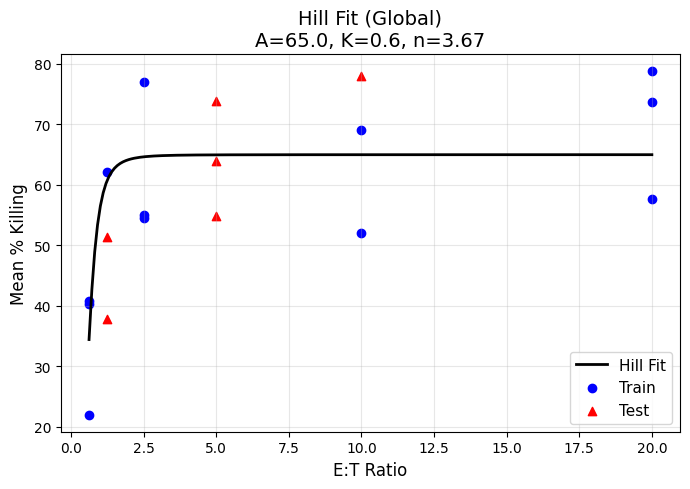

Global Hill Fit Parameters:
	A = 64.959, K = 0.605, n = 3.667
	Train R² = 0.6532, RSS = 1083.20
	Test  R² = 0.1433, RSS = 961.65


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def hill(x, A, K, n):
    return A * (x**n) / (K**n + x**n)


# === Prepare training data ===
x_train = sub_df_train["E:T"].to_numpy()
y_train = sub_df_train["Mean Result"].to_numpy()

# === Fit to all training data ===
popt, _ = curve_fit(hill, x_train, y_train, bounds=([0, 0, 0], [100, 100, 5]))
A, K, n = popt

# === Evaluate on training ===
y_train_pred = hill(x_train, A, K, n)
ss_res_train = np.sum((y_train - y_train_pred) ** 2)
ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
r2_train = 1 - ss_res_train / ss_tot_train

# === Prepare test data ===
x_test = sub_df_test["E:T"].to_numpy()
y_test = sub_df_test["Mean Result"].to_numpy()
y_test_pred = hill(x_test, A, K, n)
ss_res_test = np.sum((y_test - y_test_pred) ** 2)
ss_tot_test = np.sum((y_test - np.mean(y_test)) ** 2)
r2_test = 1 - ss_res_test / ss_tot_test

# === Plot ===
xfit = np.linspace(min(x_train.min(), x_test.min()), max(x_train.max(), x_test.max()), 200)
yfit = hill(xfit, A, K, n)

plt.figure(figsize=(7, 5))
plt.plot(xfit, yfit, color="black", linewidth=2, label="Hill Fit")
plt.scatter(x_train, y_train, color="blue", marker="o", label="Train")
plt.scatter(x_test, y_test, color="red", marker="^", label="Test")

plt.xlabel("E:T Ratio", fontsize=12)
plt.ylabel("Mean % Killing", fontsize=12)
plt.title(f"Hill Fit (Global)\nA={A:.1f}, K={K:.1f}, n={n:.2f}", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# === Print results ===
print(f"Global Hill Fit Parameters:")
print(f"\tA = {A:.3f}, K = {K:.3f}, n = {n:.3f}")
print(f"\tTrain R² = {r2_train:.4f}, RSS = {ss_res_train:.2f}")
print(f"\tTest  R² = {r2_test:.4f}, RSS = {ss_res_test:.2f}")